<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/05-Machine-Learning/02-Unsupervised-Learning/Mall_Customers_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
data=pd.read_csv(path+"/Mall_Customers.csv")

In [34]:
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


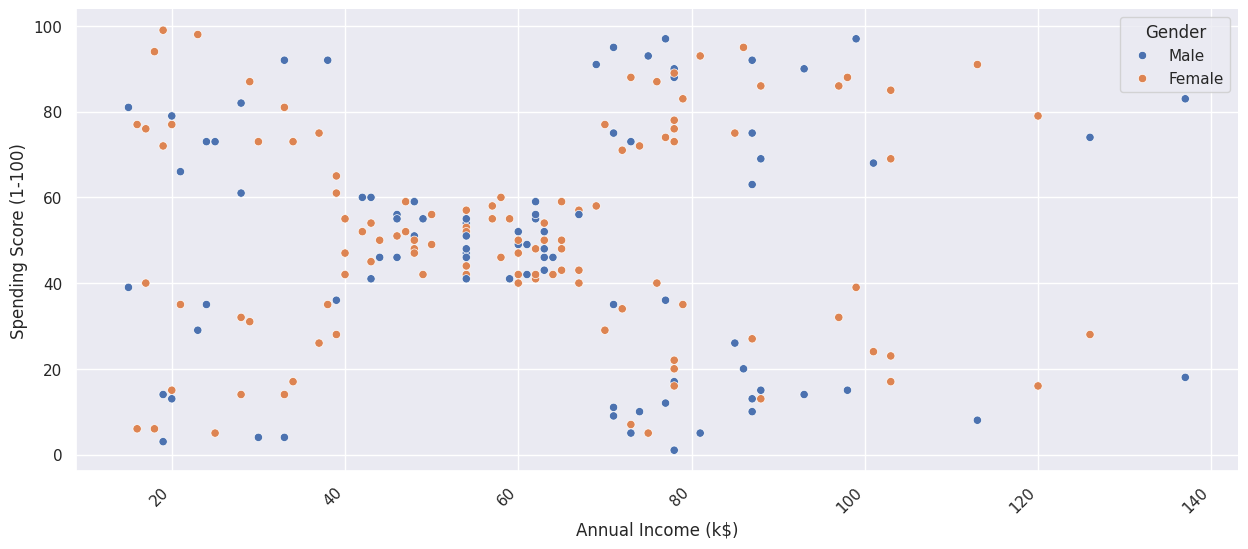

In [36]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(15,6))

sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", data=data)

plt.xticks(rotation=45,ha='right')
sns.despine()

plt.show()

In [37]:
data.drop(columns=['CustomerID'], inplace=True)

In [38]:
from sklearn.preprocessing import StandardScaler

data['Gender']=data['Gender'].map({'Male':0,'Female':1})
data.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [39]:
scaler=StandardScaler()
data=scaler.fit_transform(data)

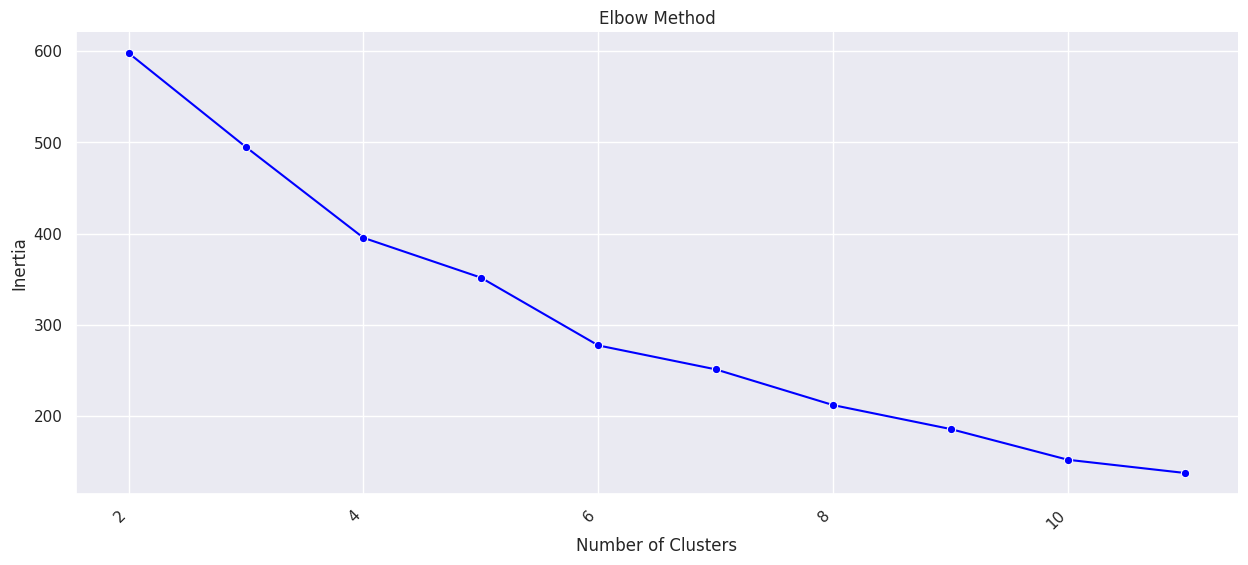

In [40]:
from matplotlib.lines import lineStyles
from sklearn.cluster import KMeans

option=range(2,12)
inertia=[]

for i in option:
    model=KMeans(n_clusters=i, random_state=42)
    model.fit(data)
    inertia.append(model.inertia_)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(15,6))

sns.lineplot(x=option, y=inertia, marker='o', color='blue')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.xticks(rotation=45,ha='right')
sns.despine()

plt.show()

In [41]:
model=KMeans(n_clusters=5, random_state=42)
model.fit(data)

KMeans(n_clusters=5, random_state=42)

In [42]:
model.cluster_centers_

array([[-0.14062401,  1.26457129, -0.55200479, -0.42262217],
       [-1.12815215,  0.04664835,  0.93858626, -1.40339942],
       [-1.12815215, -0.72911539,  0.01315937,  0.77791013],
       [ 0.88640526, -0.06832482,  0.82302637,  0.16495202],
       [ 0.88640526, -0.82777211, -0.82895964,  0.23333801]])

In [43]:
model.inertia_

351.7432061711911

In [44]:
pred=model.predict(data)
pred

array([2, 2, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 2, 4, 2, 0, 4, 2, 2,
       0, 2, 0, 2, 0, 2, 4, 4, 0, 4, 0, 2, 0, 4, 0, 4, 4, 4, 0, 2, 0, 4,
       0, 4, 0, 4, 4, 4, 0, 2, 4, 0, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0, 2,
       4, 0, 2, 4, 0, 0, 0, 0, 0, 2, 3, 2, 4, 0, 0, 2, 0, 3, 4, 0, 0, 4,
       4, 0, 0, 2, 0, 3, 4, 2, 3, 4, 0, 2, 4, 3, 0, 2, 0, 4, 0, 0, 0, 0,
       0, 4, 3, 2, 4, 4, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 1, 2, 1, 2, 1, 2,
       3, 3, 1, 3, 3, 2, 1, 3, 0, 2, 3, 3, 1, 2, 1, 3, 3, 2, 1, 2, 3, 3,
       3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3, 3, 2, 1, 2, 1, 2, 3, 3,
       1, 2, 1, 2, 3, 3, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 1, 3, 3, 3, 3, 2,
       1, 2], dtype=int32)

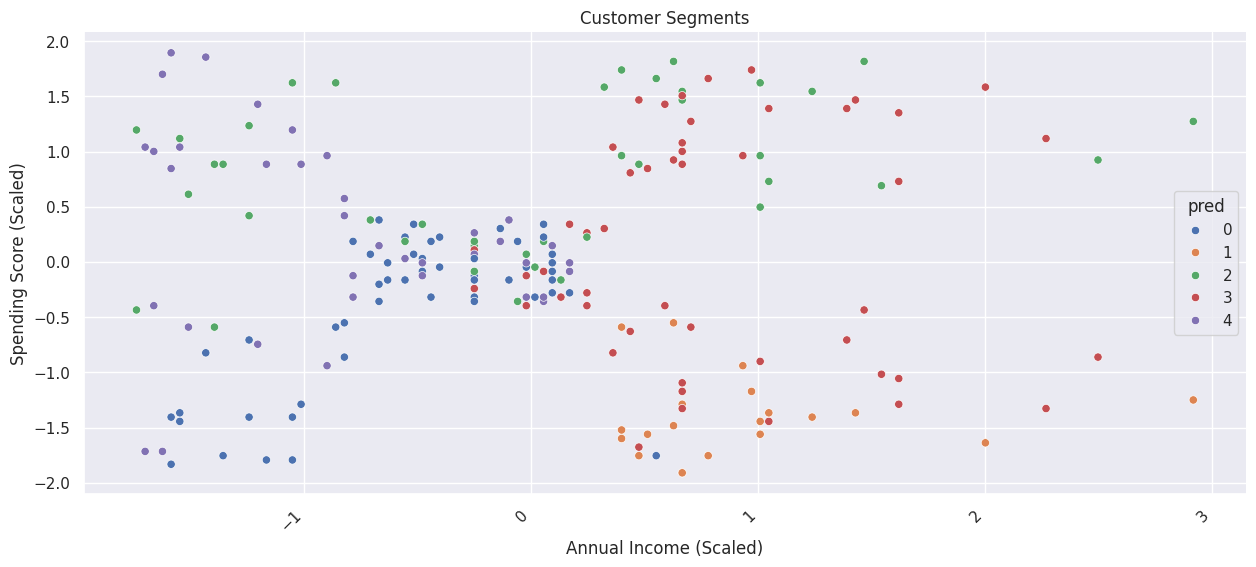

In [45]:
data1 = pd.DataFrame(data, columns=['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

data1['pred'] = pred

sns.set_theme(style="darkgrid")
plt.figure(figsize=(15,6))
plt.title('Customer Segments')

sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", hue="pred", data=data1, palette='deep')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
sns.despine()
plt.show()

### 📊 Comparative Analysis: K-Means vs. DBSCAN

While K-Means successfully partitioned the customers into 5 distinct, actionable business segments, DBSCAN struggled with this dataset.

**Key Takeaways:**
* **K-Means Success:** Because the customer segments naturally form somewhat spherical clusters based on distance partitions, K-Means excelled.
* **DBSCAN Limitation:** Because the dataset features highly varying densities (a massive, dense middle class vs. sparse outer niches), DBSCAN's fixed-radius (`eps`) approach could not cleanly separate the groups without lumping them together or marking them as noise.

In [46]:
from sklearn.cluster import DBSCAN

modelD=DBSCAN(eps=2, min_samples=10)
modelD.fit(data)

DBSCAN(eps=2, min_samples=10)

In [47]:
modelD.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [48]:
modelD.labels_

array([0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0])

## 🌌 Visualizing 4D Clusters using PCA (Principal Component Analysis)

Since our K-Means model was trained on **4 dimensions** (Gender, Age, Annual Income, and Spending Score), graphing it using just two raw columns causes the clusters to visually overlap. This happens because a standard 2D plot cannot display the boundary lines created by Age and Gender.

To solve this and visualize the true multi-dimensional separation, we apply **PCA** to reduce our 4-dimensional space into **2 Principal Components**. These components capture the maximum mathematical variance of the entire dataset, allowing us to cleanly project our 4D clusters onto a 2D screen.

In [49]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
data_pca=pca.fit_transform(data)

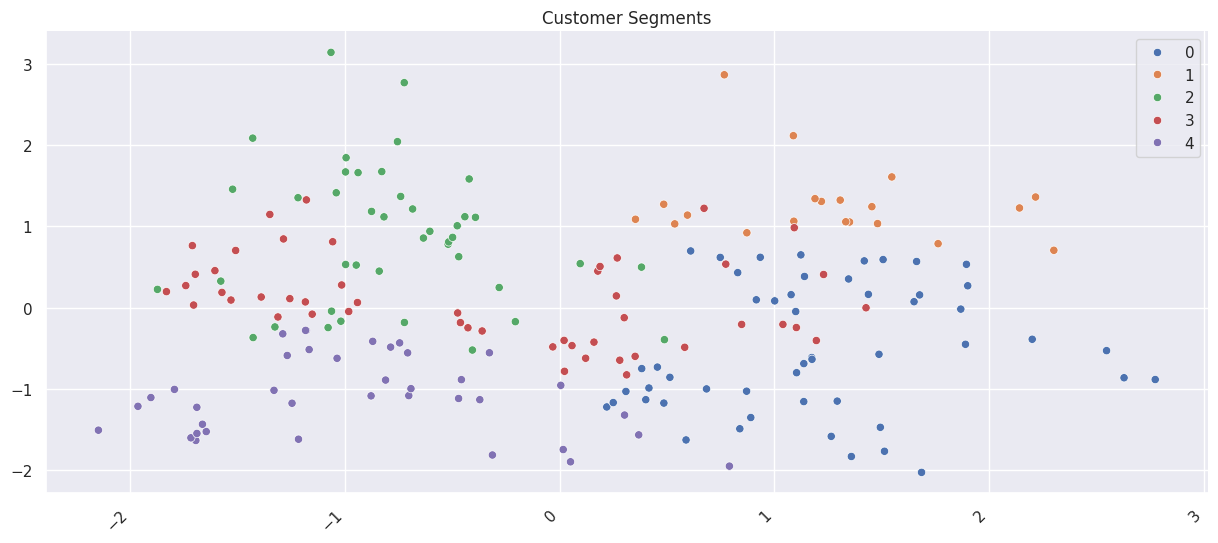

In [54]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15,6))
plt.title('Customer Segments')

sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1], hue=pred, palette='deep')

plt.xticks(rotation=45, ha='right')

sns.despine()
plt.show()